In [1]:
from datascience import *
path_data = 'data/'
import numpy as np
from scipy import stats

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


반응 변수(Response Variable) = 종속 변수(Dependent Variable) = 결과 변수(Outcome Variable)

예측 변수(Predictor Variable) = 독립 변수(Independent Variable) = 설명 변수(Explanatory Variable)

# 수치적 진단

시각화 외에도, 잔차의 수치적 속성을 사용하여 회귀의 품질을 평가할 수 있습니다. 이러한 속성들을 수학적으로 증명하지는 않을 것입니다. 대신, 계산을 통해 관찰하고 회귀에 대해 무엇을 알려주는지 살펴볼 것입니다.

아래 나열된 모든 사실은 선형이든 아니든 모든 형태의 산점도에 대해 성립합니다.

In [3]:
family_heights = Table.read_table(path_data + 'family_heights.csv')
heights = family_heights.select('midparentHeight', 'childHeight')
heights = heights.relabel(0, 'MidParent').relabel(1, 'Child')
dugong = Table.read_table(path_data + 'dugongs.csv')
dugong = dugong.move_to_start('Length')
hybrid = Table.read_table(path_data + 'hybrid.csv')

In [4]:
def standard_units(x):
    return (x - np.mean(x))/np.std(x)

def correlation(table, x, y):
    x_in_standard_units = standard_units(table.column(x))
    y_in_standard_units = standard_units(table.column(y))
    return np.mean(x_in_standard_units * y_in_standard_units)

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table.column(y))/np.std(table.column(x))

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table.column(y)) -  a * np.mean(table.column(x))

def fit(table, x, y):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

def residual(table, x, y):
    return table.column(y) - fit(table, x, y)

def scatter_fit(table, x, y):
    table.scatter(x, y, s=15)
    plots.plot(table.column(x), fit(table, x, y), lw=4, color='gold')
    plots.xlabel(x)
    plots.ylabel(y)

def residual_plot(table, x, y):
    x_array = table.column(x)
    t = Table().with_columns(
            x, x_array,
            'residuals', residual(table, x, y)
        )
    t.scatter(x, 'residuals', color='r')
    xlims = make_array(min(x_array), max(x_array))
    plots.plot(xlims, make_array(0, 0), color='darkblue', lw=4)
    plots.title('Residual Plot')

def regression_diagnostic_plots(table, x, y):
    scatter_fit(table, x, y)
    residual_plot(table, x, y)

In [5]:
heights = heights.with_columns(
        'Fitted Value', fit(heights, 'MidParent', 'Child'),
        'Residual', residual(heights, 'MidParent', 'Child')
    )

## 잔차 플롯은 추세를 보이지 않음
**좋든 나쁘든 모든 선형 회귀에 대해, 잔차 플롯은 추세를 보이지 않습니다. 전체적으로 평평합니다. 즉, 잔차와 예측 변수는 상관관계가 없습니다.**

위의 모든 잔차 플롯에서 이것을 볼 수 있습니다. 각 경우에 예측 변수와 잔차 간의 상관관계를 계산할 수도 있습니다.



In [6]:
correlation(heights, 'MidParent', 'Residual')

-2.7196898076470642e-16

이것은 0처럼 보이지 않지만, 계산으로 인한 반올림 오차를 제외하면 0인 매우 작은 숫자입니다. 소수점 10자리까지 정확하게 표시하면 다음과 같습니다. 음수 부호는 위의 반올림 때문입니다.

In [7]:
round(correlation(heights, 'MidParent', 'Residual'), 10)

-0.0

In [8]:
dugong = dugong.with_columns(
       'Fitted Value', fit(dugong, 'Length', 'Age'),
       'Residual', residual(dugong, 'Length', 'Age')
)
round(correlation(dugong, 'Length', 'Residual'), 10)

0.0

## 잔차의 평균
**산점도의 형태가 무엇이든, 잔차의 평균은 0입니다.**

이는 어떤 숫자 목록을 가져와서 평균으로부터의 편차 목록을 계산하면, 편차의 평균이 0이라는 사실과 유사합니다.

위의 모든 잔차 플롯에서, 플롯의 중심을 지나는 0의 수평선을 보았습니다. 이것이 이 사실의 시각화입니다.

수치적 예로, 다음은 중간 부모 키를 기반으로 한 자녀 키의 회귀에서 잔차의 평균입니다.

In [9]:
round(np.mean(heights.column('Residual')), 10)

0.0

듀공의 길이에 대한 나이의 회귀에서 잔차의 평균도 마찬가지입니다. 반올림 오차를 제외하면 잔차의 평균은 0입니다.

In [10]:
round(np.mean(dugong.column('Residual')), 10)

0.0

## 잔차의 표준편차
**산점도의 형태가 무엇이든, 잔차의 표준편차는 반응 변수의 표준편차의 일부입니다. 그 비율은 $\sqrt{1-r^2}$입니다.**

$$
\mbox{SD of residuals} ~=~ \sqrt{1 - r^2} \cdot \mbox{SD of }y
$$

이것이 회귀 추정의 정확도를 어떻게 측정하는지 곧 살펴볼 것입니다. 하지만 먼저, 예제로 이를 확인해 봅시다.

자녀 키와 중간 부모 키의 경우, 잔차의 표준편차는 약 3.39인치입니다.

In [11]:
np.std(heights.column('Residual'))

3.3880799163953426

이는 반응 변수의 표준편차에 $\sqrt{1-r^2}$를 곱한 것과 같습니다:

In [12]:
r = correlation(heights, 'MidParent', 'Child')
np.sqrt(1 - r**2) * np.std(heights.column('Child'))

3.3880799163953421

하이브리드 자동차의 가속도에 대한 연비의 회귀에서도 마찬가지입니다. 상관관계 $r$은 음수(약 -0.5)이지만, $r^2$은 양수이므로 $\sqrt{1-r^2}$는 분수입니다.

In [13]:
r = correlation(hybrid, 'acceleration', 'mpg')
r

-0.5060703843771186

In [14]:
hybrid = hybrid.with_columns(
     'fitted mpg', fit(hybrid, 'acceleration', 'mpg'),
     'residual', residual(hybrid, 'acceleration', 'mpg')
)
np.std(hybrid.column('residual')), np.sqrt(1 - r**2)*np.std(hybrid.column('mpg'))

(9.4327368334302903, 9.4327368334302903)

이제 잔차의 표준편차가 회귀가 얼마나 좋은지를 측정하는 방법을 살펴봅시다. 잔차의 평균이 0이라는 것을 기억하세요. 따라서 잔차의 표준편차가 작을수록, 잔차는 0에 더 가깝습니다. 즉, 잔차의 표준편차가 작으면 회귀의 전체 오차 크기가 작습니다.

극단적인 경우는 $r=1$ 또는 $r=-1$일 때입니다. 두 경우 모두 $\sqrt{1-r^2} = 0$입니다. 따라서 잔차는 평균이 0이고 표준편차도 0이며, 따라서 잔차는 모두 0과 같습니다. 회귀선은 추정을 완벽하게 수행합니다. 이 장 앞에서 보았듯이, $r = \pm 1$이면 산점도는 완벽한 직선이고 회귀선과 같으므로, 실제로 회귀 추정에는 오차가 없습니다.

그러나 보통 $r$은 극단값에 있지 않습니다. $r$이 $\pm 1$도 0도 아니면, $\sqrt{1-r^2}$는 진분수이고, 회귀 추정 오차의 대략적인 전체 크기는 0과 $y$의 표준편차 사이 어딘가에 있습니다.

최악의 경우는 $r = 0$일 때입니다. 그러면 $\sqrt{1-r^2} =1$이고, 잔차의 표준편차는 $y$의 표준편차와 같습니다. 이는 $r=0$이면 회귀선이 $y$의 평균에서 평평한 선이라는 관찰과 일치합니다. 이 상황에서 회귀의 평균 제곱근 오차는 $y$의 평균으로부터의 평균 제곱 편차의 제곱근이며, 이는 $y$의 표준편차입니다. 실용적으로, $r = 0$이면 두 변수 간에 선형 연관성이 없으므로 선형 회귀를 사용하는 이점이 없습니다.

## $r$을 해석하는 또 다른 방법
위의 결과를 다시 작성하면 산점도의 형태가 무엇이든,

$$
\frac{\mbox{SD of residuals}}{\mbox{SD of }y} ~=~ \sqrt{1-r^2}
$$

보완적인 결과는 산점도의 형태가 무엇이든, 적합값의 표준편차는 $y$의 관측값의 표준편차의 일부라는 것입니다. 그 비율은 $\vert r \vert$입니다.

$$
\frac{\mbox{SD of fitted values}}{\mbox{SD of }y} ~=~ \vert r \vert
$$

비율이 어디에서 나오는지 보려면, 적합값은 모두 회귀선 위에 있는 반면 $y$의 관측값은 산점도의 모든 점의 높이이고 더 가변적이라는 것을 주목하세요.

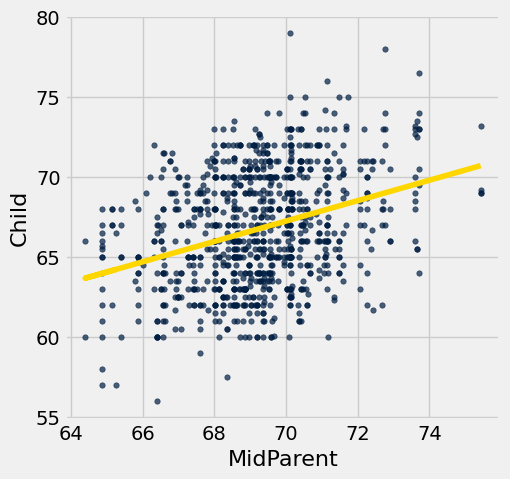

In [15]:
scatter_fit(heights, 'MidParent', 'Child')

적합값은 약 64에서 약 71까지 범위이지만, 모든 자녀의 키는 약 55에서 80까지 범위로 훨씬 더 가변적입니다.

결과를 수치적으로 검증하려면, 항등식의 양변을 계산하기만 하면 됩니다.

In [16]:
correlation(heights, 'MidParent', 'Child')

0.32094989606395924

다음은 적합값의 표준편차와 출생 체중의 관측값의 표준편차의 비율입니다:

In [17]:
np.std(heights.column('Fitted Value'))/np.std(heights.column('Child'))

0.32094989606395957

비율은 $r$과 같으며, 우리의 결과를 확인해 줍니다.

절댓값은 어디서 나올까요? 먼저 표준편차는 음수가 될 수 없으므로, 표준편차의 비율도 음수가 될 수 없다는 것을 주목하세요. 그렇다면 $r$이 음수일 때는 어떻게 될까요? 연비와 가속도의 예가 보여줄 것입니다.

In [18]:
correlation(hybrid, 'acceleration', 'mpg')

-0.5060703843771186

In [19]:
np.std(hybrid.column('fitted mpg'))/np.std(hybrid.column('mpg'))

0.5060703843771186

두 표준편차의 비율은 $\vert r \vert$입니다.

이 결과를 표현하는 더 표준적인 방법은 다음을 기억하는 것입니다

$$
\mbox{variance} ~=~ \mbox{mean squared deviation from average} ~=~ \mbox{SD}^2
$$

따라서, 우리 결과의 양변을 제곱하면,

$$
\frac{\mbox{variance of fitted values}}{\mbox{variance of }y} ~=~ r^2
$$